In [ ]:
!pip install pyspark --quiet

In [ ]:
from pyspark.sql import SparkSession
#Sparksession is the single entry point to all pyspark functiinality
#thik of it  like :conn=sqlite3.connect() from day2
#without sparksession pysaprk nothing works

from pyspark.sql import functions as f #function module  all buil in cloumn function f.sum(),f.avg(), f.count()
from pyspark.sql.functions import year,month,to_date,col,round as spark_round

import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
spark=SparkSession.builder\
    .appName('Day4_BigData_Sales')\
    .config('spark.sql.adaptive.enabled', 'true')\
    .getOrCreate()


  #.BUILDER   =CREATES sparksesion builde
  #appName(...)  =name shown in spark logs
#.congig(..)  =enables Adaptive query Exeution (optimizes plan automatically)
#.getorCreate()   =cerates new session or results existing one
#important always  .getorCreate() not .create()

print(spark.version)

4.0.2


In [ ]:
df_bronze=spark.read \
          .option('header','true') \
          .option('inferSchema' ,'true') \
          .csv('/content/drive/MyDrive/Colab Notebooks/Datasets/large_sales_data.csv')


print("Bronzelayer")

print(f"Rows :{df_bronze.count()}")
print(f"Columns : {len(df_bronze.columns)}")

df_bronze.printSchema()

Bronzelayer
Rows :5000
Columns : 13
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)



In [ ]:
print("First 5 rows")
df_bronze.show(5,truncate=False)
#.show(n)
#truncate=False
#Like df.head(5) in pandas but formatted as an ASCII

print('\nBasic statitsics for numeric columns:')
df_bronze.select('quantity','unit_price','revenue').describe().show()
#.select is a TRANSFORMATION=picks specific columns
#.describe() ACTION=compute coun,mean,stdev,min,max
#Live df.describe() in pandas

First 5 rows
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|order_id|customer_name|product   |category   |quantity|unit_price|revenue|order_date|city     |region|sales_rep  |payment_method  |order_status|
+--------+-------------+----------+-----------+--------+----------+-------+----------+---------+------+-----------+----------------+------------+
|1001    |Sneha Reddy  |Monitor   |Electronics|12      |22000     |264000 |2023-05-21|Mumbai   |West  |Meera Patel|UPI             |Delivered   |
|1002    |Ramesh Kumar |Printer   |Electronics|10      |12000     |120000 |2023-08-05|Delhi    |North |Anil Sharma|Credit Card     |Shipped     |
|1003    |Rahul Mishra |Mouse     |Accessories|10      |800       |8000   |2023-01-14|Ahmedabad|West  |Meera Patel|Cash on Delivery|Shipped     |
|1004    |Suresh Rao   |Tablet    |Electronics|5       |32000     |160000 |2023-01-04|Surat    |West  |Ravi Kum

In [ ]:
df_bronze.write \
    .mode('overwrite') \
    .parquet('sales_bronze.parquet')

    #df.write    =dataframe object
    #.mode(overwriite)   =replace file if already exists
    #other words   :'append' (add to existing)if available 'ignore'



    #compare file siZes
import os

def get_dir_size(path):
  if os.path.isfile(path):
    return os.path.getsize(path)/1024
  total=0
  for dirpath ,dirname,filename in os.walk(path):
    for f in filename:
      total==os.path.getsize(os.path.join(dirpath,f))
  return total/1024

csv_size  =get_dir_size('/content/drive/MyDrive/Colab Notebooks/Datasets/large_sales_data.csv')
parquet_size =get_dir_size('/content/drive/MyDrive/Colab Notebooks/Datasets/sales_bronze.parquet')
reduction  =(1-parquet_size/csv_size)*100

print(f"CSv Size:{csv_size:.1f}KB")
print(f"Parquet Size:{parquet_size:.1f}KB")
print(f"At 1 Tb scale :{1000*(reduction/100):.0f}GB")

CSv Size:529.3KB
Parquet Size:0.0KB
At 1 Tb scale :1000GB


SILVER

In [ ]:
df_silver=df_bronze \
.dropDuplicates() \
.dropna(subset=['order_id','product','revenue'])


df_silver=df_silver.withColumn(
    'order_date',
    to_date(col('order_date'),'yyyy-NN-dd')
)

df_silver=df_silver \
  .withColumn('order_year',year(col('order_date'))) \
  .withColumn('order_month',month(col('order_date')))

df_silver=df_silver.withColumn(
    'revenue_category',
    f.when(col('revenue')>40000,'High')
    .when(col('revenue')>10000,'Medium')
    .otherwise('Low')
)

print(f"Silver layer rows: {df_silver.count()}")
print("New Columns added:order_year,order_month,revenue_category")
df_silver.select('product','revenue','order_year','order_month','revenue_category')

Silver layer rows: 5000
New Columns added:order_year,order_month,revenue_category


DataFrame[product: string, revenue: int, order_year: int, order_month: int, revenue_category: string]

In [ ]:
df_silver.write \
.mode('overwrite') \
.parquet('sales_silver.parquet')



df_verify=spark.read.parquet('sales_silver.parquet')
print(f"Silver layer rows: {df_verify.count()}")
df_verify.printSchema()


Silver layer rows: 5000
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_year: integer (nullable = true)
 |-- order_month: integer (nullable = true)
 |-- revenue_category: string (nullable = true)



In [ ]:
top_products=df_silver \
  .groupBy('product') \
  .agg(
      f.sum('revenue').alias('total_revenue'),
      f.count('order_id').alias('num_orders'),
      f.round(f.avg('revenue'),2).alias('avg_order_revenue')
  ) \
  .orderBy('total_revenue',ascending=False) \
  .limit(5)
print("Top 5 prducts by revenue")
top_products.show(truncate=False)

Top 5 prducts by revenue
+-------+-------------+----------+-----------------+
|product|total_revenue|num_orders|avg_order_revenue|
+-------+-------------+----------+-----------------+
|Laptop |182700000    |502       |363944.22        |
|Tablet |135104000    |532       |253954.89        |
|Monitor|82126000     |481       |170740.12        |
|Printer|44544000     |488       |91278.69         |
|Speaker|16317000     |470       |34717.02         |
+-------+-------------+----------+-----------------+



In [ ]:
region=df_silver \
.groupby('region') \
.agg(
    f.sum('revenue').alias('total_revenue'),
    f.count('order_id').alias('num_orders'),
    f.round(f.avg('revenue'),2).alias('avg_order_revenue')
) \
.orderBy('total_revenue',ascending=False
)
region.show(truncate=False)

+------+-------------+----------+-----------------+
|region|total_revenue|num_orders|avg_order_revenue|
+------+-------------+----------+-----------------+
|West  |198275600    |2021      |98107.67         |
|South |147145900    |1483      |99221.78         |
|North |99878400     |995       |100380.3         |
|East  |50547700     |501       |100893.61        |
+------+-------------+----------+-----------------+



In [ ]:
monthly_revenue=df_silver \
  .withColumn('month_name', f.date_format(f.col('order_date'), 'MMMM')) \
.groupby('order_month', 'month_name') \
.agg(
    f.sum('revenue').alias('total_revenue'),
    f.count('order_id').alias('num_orders')\
) \
.orderBy(f.col('order_month').asc()).select('month_name', 'total_revenue', 'num_orders')

monthly_revenue.show(12)

+----------+-------------+----------+
|month_name|total_revenue|num_orders|
+----------+-------------+----------+
|   January|     41068200|       423|
|  February|     34485400|       375|
|     March|     40031200|       451|
|     April|     38857100|       390|
|       May|     39984500|       423|
|      June|     40707400|       390|
|      July|     42640700|       405|
|    August|     43718500|       418|
| September|     37640200|       398|
|   October|     47839000|       479|
|  November|     44577100|       419|
|  December|     44298300|       429|
+----------+-------------+----------+



Gold Layer

In [ ]:
gold_region = region
gold_region.write.mode('overwrite').parquet('/content/drive/MyDrive/Colab Notebooks/Datasets/gold_region.parquet')
print('Gold Parquet 1 saved: sales_gold_region.praquet')

gold_product = df_silver \
               .groupBy('product', 'category') \
               .agg(
                   f.sum('revenue').alias('total_revenue'),
                   f.count('order_id').alias('order_count'),
                   spark_round(f.avg('revenue'),2).alias('avg_revenue'),
                   f.max('revenue').alias('largest_order')
               ) \
               .orderBy('total_revenue', ascending = False)
gold_product.write.mode('overwrite').parquet('/content/drive/MyDrive/Colab Notebooks/Datasets/gold_product.parquet')
print('Gold Parquet 2 saved: sales_gold_product.praquet')

gold_monthly = monthly_revenue
gold_monthly.write.mode('overwrite').parquet('/content/drive/MyDrive/Colab Notebooks/Datasets/gold_monthly.parquet')
print('Gold Parquet 3 saved: sales_gold_monthly.praquet')

Gold Parquet 1 saved: sales_gold_region.praquet
Gold Parquet 2 saved: sales_gold_product.praquet
Gold Parquet 3 saved: sales_gold_monthly.praquet


In [ ]:
!pip install twilio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 40.8 MB/s eta 0:00:00


In [ ]:
import os
from getpass import getpass
from twilio.rest import Client


# --- Twilio credentials ---
TW_SID = os.environ.get('')
TW_TOKEN = os.environ.get('')


if not TW_SID or not TW_TOKEN:
    print("Enter your Twilio Account SID and Auth Token:")
    TW_SID = getpass("Twilio SID: ")
    TW_TOKEN = getpass("Twilio Token: ")
    os.environ['TWILIO_SID'] = TW_SID
    os.environ['TWILIO_TOKEN'] = TW_TOKEN





Enter your Twilio Account SID and Auth Token:


KeyboardInterrupt: Interrupted by user

In [ ]:
FROM='whatsapp:+14155238886.'

TO=input('Enter your whatsapp number').strip()

if not TO.startswith('whatsapp'):
  TO=f'whatsapp:{TO}'

client=Client(TW_SID,TW_TOKEN)

msg=client.messages.create(
    body='Hello from twillio Whatsapp Sandbox',
    from_=FROM,
    to=TO
)

print('Message sent successfully')
print('Message SID:',msg.sid)

In [ ]:
gold_monthly.show(5)

+----------+-------------+----------+
|month_name|total_revenue|num_orders|
+----------+-------------+----------+
|   January|     41068200|       423|
|  February|     34485400|       375|
|     March|     40031200|       451|
|     April|     38857100|       390|
|       May|     39984500|       423|
+----------+-------------+----------+
only showing top 5 rows


In [ ]:
gold_product.show(5)

+-------+-----------+-------------+-----------+-----------+-------------+
|product|   category|total_revenue|order_count|avg_revenue|largest_order|
+-------+-----------+-------------+-----------+-----------+-------------+
| Laptop|Electronics|    182700000|        502|  363944.22|       675000|
| Tablet|Electronics|    135104000|        532|  253954.89|       480000|
|Monitor|Electronics|     82126000|        481|  170740.12|       330000|
|Printer|Electronics|     44544000|        488|   91278.69|       180000|
|Speaker|Electronics|     16317000|        470|   34717.02|        67500|
+-------+-----------+-------------+-----------+-----------+-------------+
only showing top 5 rows


In [ ]:
region_pd=spark.read.parquet('/content/drive/MyDrive/Colab Notebooks/Datasets/gold_region.parquet').toPandas()
product_pd=spark.read.parquet('/content/drive/MyDrive/Colab Notebooks/Datasets/gold_product.parquet').toPandas()
monthly_pd=spark.read.parquet('/content/drive/MyDrive/Colab Notebooks/Datasets/gold_monthly.parquet').toPandas()

print(f"Region shape:{region_pd.shape}")
print(f"product shape:{product_pd.shape}")
print(f"Mpnthly shape:{monthly_pd.shape}")

#sort for plotting
region_pd=region_pd.sort_values('total_revenue',ascending=False)
product_pd=product_pd.sort_values('total_revenue',ascending=False)
monthly_pd=monthly_pd.sort_values('month_name')

Region shape:(4, 4)
product shape:(10, 6)
Mpnthly shape:(12, 3)


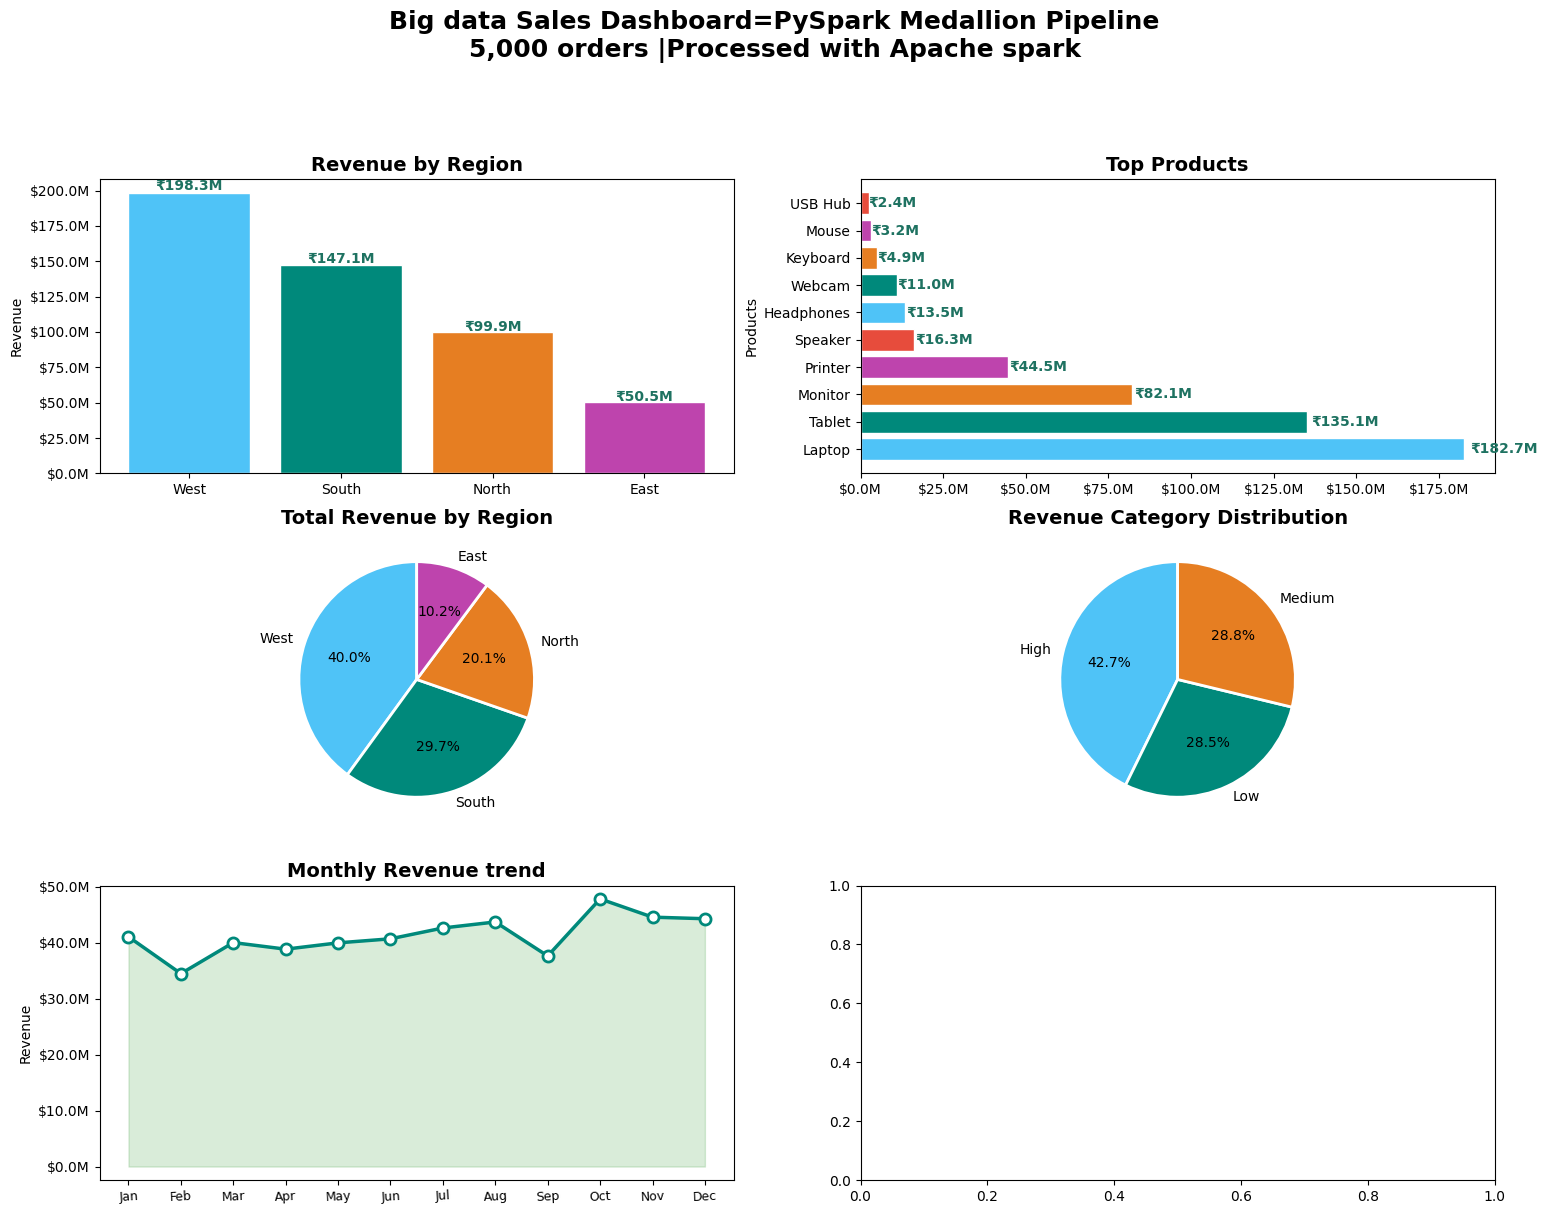

In [ ]:
import calendar

fig,axes=plt.subplots(3,2,figsize=(18,13))
fig.suptitle(
    'Big data Sales Dashboard=PySpark Medallion Pipeline\n'
    '5,000 orders |Processed with Apache spark',
    fontsize=18,fontweight='bold',color='black',y=1.01
)
colors4=['#4FC3F7','#00897B','#E67E22','#BE44AD','#E74C3C']

#panel1n  Revenue by region

ax1=axes[0][0]
bars1=ax1.bar(region_pd['region'],region_pd['total_revenue'],
              color=colors4[:len(region_pd)],edgecolor='white')

for bar in bars1:
  ax1.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,
           f'₹{bar.get_height()/1e6:.1f}M',
  ha='center',fontsize=10,fontweight='bold',color='#1E7261')


ax1.set_title('Revenue by Region',fontsize=14,fontweight='bold')
ax1.set_ylabel('Revenue')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda X,_: f'${X/1e6:.1f}M'))


#panel2 top products in horizontal bar

ax2=axes[0][1]
bars2=ax2.barh(product_pd['product'],product_pd['total_revenue'],
              color=colors4[:len(product_pd)],edgecolor='white')

for bar in bars2:
    ax2.text(
        bar.get_width() * 1.01,bar.get_y() + bar.get_height()/2,
        f'₹{bar.get_width()/1e6:.1f}M',va='center',fontsize=10,fontweight='bold',color='#1E7261'
    )


ax2.set_title('Top Products',fontsize=14,fontweight='bold')
ax2.set_ylabel('Products')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda X,_: f'${X/1e6:.1f}M'))


#panel3

ax3 = axes[1, 0]
ax3.pie(
    region_pd['total_revenue'],
    labels=region_pd['region'],
    colors=colors4[:len(region_pd)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

ax3.set_title("Total Revenue by Region", fontsize=14, fontweight='bold')

#panel4

ax4 = axes[1, 1]
rev_cat = df_silver.groupBy('revenue_category').count().toPandas()
ax4.pie(rev_cat['count'],
        labels=rev_cat['revenue_category'],
        colors=colors4[:len(rev_cat)],
        autopct='%1.1f%%',startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2})
ax4.set_title('Revenue Category Distribution',fontsize=14,fontweight='bold')

#panel5

ax5=axes[2][0]

month_full_to_num = {name: i for i, name in enumerate(calendar.month_name) if i}
monthly_pd['month_num_for_sort'] = monthly_pd['month_name'].map(month_full_to_num)

monthly_pd = monthly_pd.sort_values(by='month_num_for_sort').drop(columns='month_num_for_sort')

month_names_abbr=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_labels=[month_names_abbr[month_full_to_num[full_name]-1] for full_name in monthly_pd['month_name']]

ax5.plot(monthly_labels,monthly_pd['total_revenue'],marker='o',linewidth=2.5,color='#00897B',
         markersize=8,markerfacecolor='white',markeredgewidth=2)
ax5.fill_between(range(len(monthly_labels)),
                 monthly_pd['total_revenue'],
                 alpha=0.15,color='green')
ax5.set_title('Monthly Revenue trend',fontsize=14,fontweight='bold')
ax5.set_ylabel('Revenue')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda X,_: f'${X/1e6:.1f}M'))
ax5.tick_params(axis='x',rotation=3,labelsize=9)